In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1 (1).csv")
print(df.head())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None


In [4]:
print(df.shape)

(1200, 14)


In [5]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


In [6]:
print(df.describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


Understanding spending patterns helps the business create pricing strategies and targeted promotional campaigns.

In [7]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


The dataset contains minimal missing values, indicating good data quality. Reliable data improves the accuracy of business decisions and analytical outcomes.

In [8]:
product_sales = df.groupby("Product")["TotalPrice"].sum()
print(product_sales.sort_values(ascending=False))

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


Certain products such as Printer, Chair, and Laptop generate significantly more revenue than others. These products represent key revenue contributors within the product portfolio.

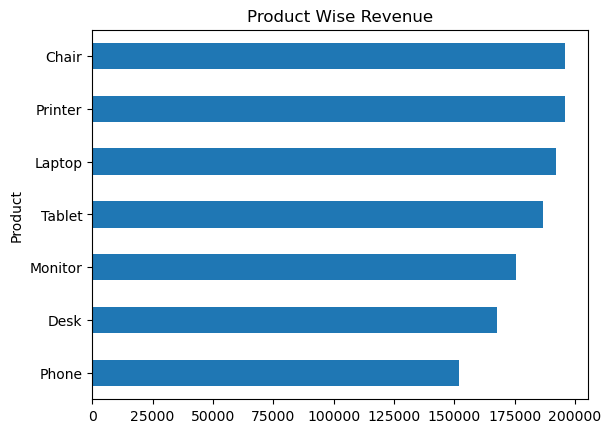

In [9]:
product_sales.sort_values().plot(kind="barh")
plt.title("Product Wise Revenue")
plt.show()

Certain products such as Printer, Chair, and Laptop generate significantly more revenue than others. These products represent key revenue contributors within the product portfolio.

In [10]:
payment = df["PaymentMethod"].value_counts()
print(payment)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


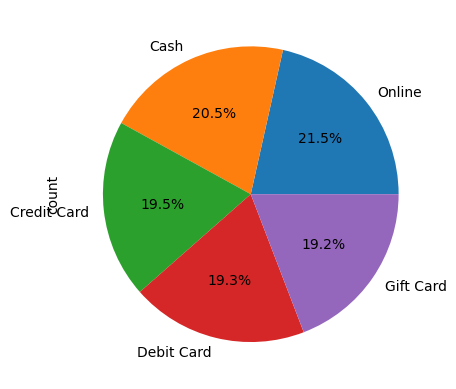

In [11]:
payment.plot(kind="pie", autopct="%1.1f%%")
plt.show()

Continue optimizing digital payment experiences and provide incentives for online transactions to improve customer convenience.

In [12]:
status = df["OrderStatus"].value_counts()
print(status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


While most orders are cancelled or returned. These orders directly impact profitability and customer satisfaction. Investigate the causes of cancellations and returns to reduce revenue leakage and improve operational efficiency.

In [13]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()
print(monthly_revenue)

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


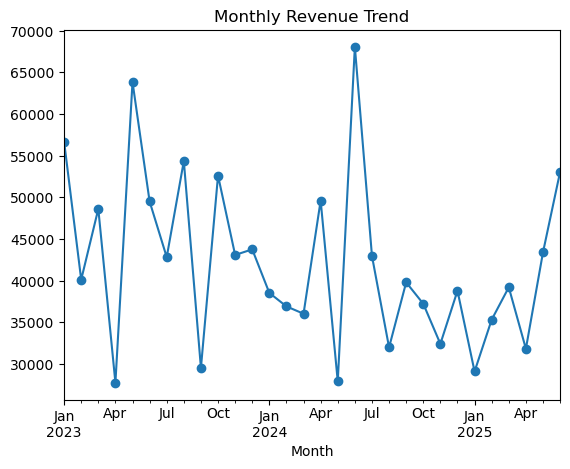

In [14]:
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.show()

Monthly revenue fluctuates throughout the year, indicating changes in customer demand over time. Some months perform better than others, suggesting possible seasonal purchasing patterns.

In [15]:
referral_sales = df.groupby("ReferralSource")["TotalPrice"].sum()
print(referral_sales.sort_values(ascending=False))

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


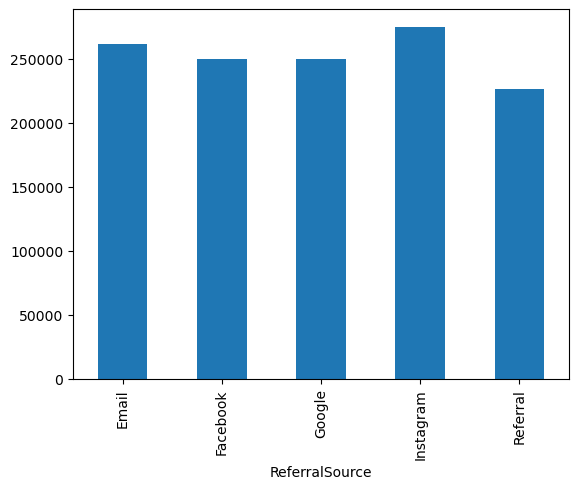

In [16]:
referral_sales.plot(kind="bar")
plt.show()

Instagram generates the highest revenue among referral sources, making it the most effective customer acquisition channel.

In [17]:
coupon = df.groupby("CouponCode")["TotalPrice"].sum()
print(coupon)

CouponCode
FREESHIP    335036.99
SAVE10      304840.02
WINTER15    302483.54
Name: TotalPrice, dtype: float64


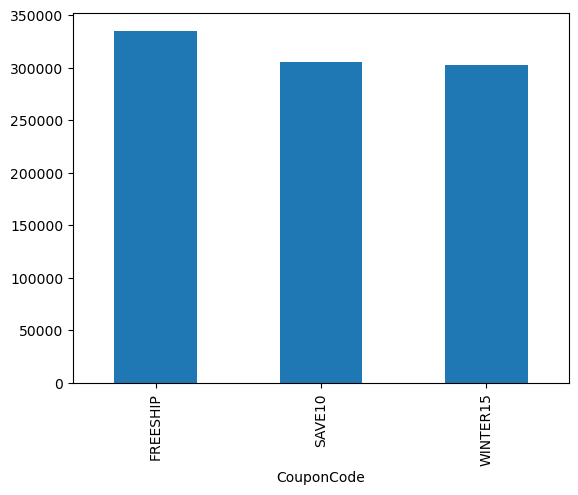

In [18]:
coupon.plot(kind="bar")
plt.show()

The 'FREESHIP' coupon works well than other coupons so, we can give more coupons to increase sales Focus future promotional campaigns on the most effective coupon strategies to maximize conversion rates.

In [19]:
top_customers = df.groupby("CustomerID")["TotalPrice"].sum()
print(top_customers.sort_values(ascending=False).head(10))

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64


Customer C38840 is the highest-value customer with a total spending of ₹5,723.23. This customer contributes significantly more revenue than the average customer and may be considered a high-value customer for retention and loyalty programs.

In [20]:
print(df["Quantity"].describe())

count    1200.000000
mean        2.945833
std         1.407557
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64


Customers purchase approximately three items per transaction on average. The distribution suggests balanced purchasing behavior across the customer base.

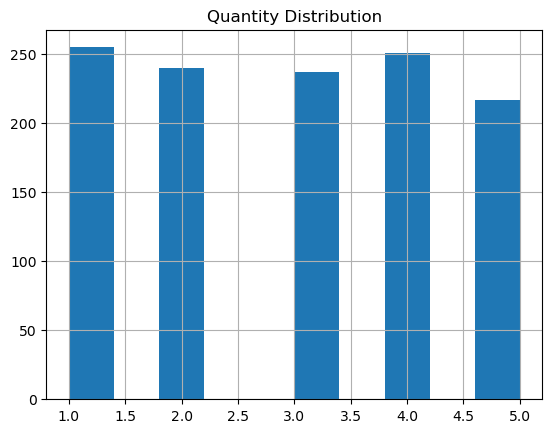

In [21]:
df["Quantity"].hist(bins=10)
plt.title("Quantity Distribution")
plt.show()

In [22]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["TotalPrice"] < lower) |
              (df["TotalPrice"] > upper)]
print(outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Cancelled  

Eight transactions were identified as outliers due to exceptionally high order values. These transactions contribute significantly to overall revenue. Analyze these high-value orders separately to understand customer characteristics and replicate similar purchasing behavior.

In [23]:
numeric_cols = ["Quantity",
                "UnitPrice",
                "ItemsInCart",
                "TotalPrice"]
corr = df[numeric_cols].corr()
print(corr)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


UnitPrice has the strongest relationship with TotalPrice (0.717), followed by Quantity (0.615). This indicates that revenue growth is driven primarily by product pricing and purchase quantity.

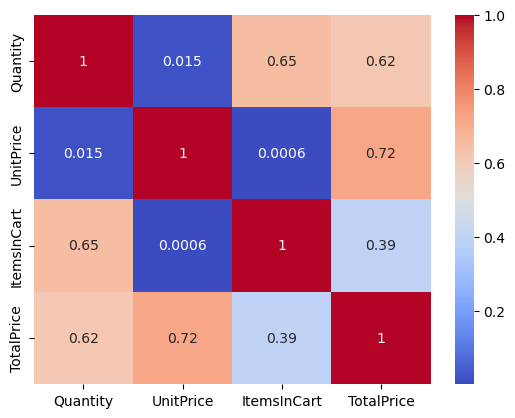

In [24]:
import seaborn as sns
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

The heatmap confirms strong positive relationships among revenue-related variables. No significant negative relationships are observed.

In [25]:
revenue = df.groupby("Product")["TotalPrice"].sum()
print(revenue.sort_values(ascending=False))

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


Chair generated the highest revenue, followed closely by Printer and Laptop. These products represent the most profitable categories.

In [26]:
avg_order = df["TotalPrice"].mean()
print("Average Order Value =", avg_order)

Average Order Value = 1053.9683


The average customer spends approximately ₹1,054 per transaction.

In [27]:
purchase_frequency = df["CustomerID"].value_counts()
print(purchase_frequency.head(10))

CustomerID
C14847    2
C98474    2
C21191    2
C46651    2
C97593    2
C56969    2
C35852    2
C38840    2
C94569    2
C70659    2
Name: count, dtype: int64


Most customers appear only once in the dataset, indicating a low repeat purchase rate. Develop retention strategies such as loyalty programs, personalized recommendations, and follow-up marketing campaigns.

In [28]:
print("Total Revenue:", df["TotalPrice"].sum())

print("Average Revenue:",
      df["TotalPrice"].mean())

print("Total Orders:",
      df["OrderID"].nunique())

print("Total Customers:",
      df["CustomerID"].nunique())

print("Most Sold Product:",
      df["Product"].mode()[0])

Total Revenue: 1264761.96
Average Revenue: 1053.9683
Total Orders: 1200
Total Customers: 1189
Most Sold Product: Printer


The business generated over ₹12.64 lakh in revenue, demonstrating strong overall sales performance.